# 01 — V5 Data Pipeline (Reproducibility Notebook)

**BBL514E Pattern Recognition — Term Project**

V5 data pipeline outputs:
- BTC OHLCV (Sep 2014 →) and ETH OHLCV (Aug 2017 →)
- 16 macro features (S&P 500, VIX, DXY, Gold/Silver, Oil, US10Y/US2Y, Fed Funds, CPI, Unemployment, M2, etc.)
- Macro-only pretrain features (Jan 2000 → Dec 2025) for Stage 2 macro regime classifier fit

Bu notebook V5 raw + processed CSV'lerini yükleyip sanity check yapar.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})
proc = PROJECT_ROOT / "data" / "processed"
raw  = PROJECT_ROOT / "data" / "raw" 

## 1. BTC / ETH price history (raw)

BTC: 4123 rows, 2014-09-17 -> 2025-12-30
ETH: 2974 rows, 2017-11-09 -> 2025-12-30


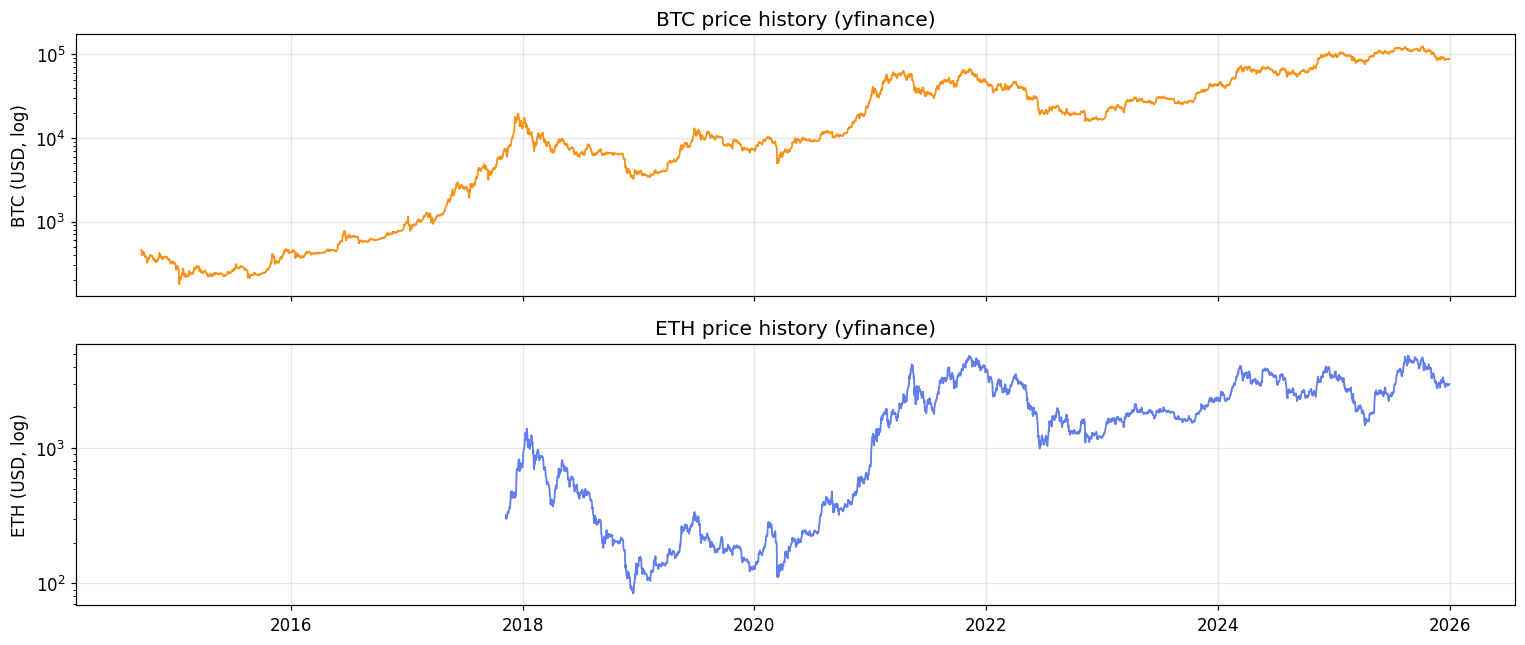

In [2]:
btc_raw = pd.read_csv(raw / "v5_price_btc.csv", index_col=0, parse_dates=True)
eth_raw = pd.read_csv(raw / "v5_price_eth.csv", index_col=0, parse_dates=True)
print(f"BTC: {btc_raw.shape[0]} rows, {btc_raw.index.min().date()} -> {btc_raw.index.max().date()}")
print(f"ETH: {eth_raw.shape[0]} rows, {eth_raw.index.min().date()} -> {eth_raw.index.max().date()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].semilogy(btc_raw.index, btc_raw["Close"], color="#F7931A", lw=1.2)
axes[0].set_ylabel("BTC (USD, log)")
axes[0].set_title("BTC price history (yfinance)")
axes[1].semilogy(eth_raw.index, eth_raw["Close"], color="#627EEA", lw=1.2)
axes[1].set_ylabel("ETH (USD, log)")
axes[1].set_title("ETH price history (yfinance)")
fig.tight_layout()
plt.show()

## 2. Macro features (raw): risk + yields + commodities + monthly FRED

In [3]:
macro_risk    = pd.read_csv(raw / "v5_macro_risk.csv",        index_col=0, parse_dates=True)
macro_yields  = pd.read_csv(raw / "v5_macro_yields.csv",      index_col=0, parse_dates=True)
macro_comms   = pd.read_csv(raw / "v5_macro_commodities.csv", index_col=0, parse_dates=True)
macro_monthly = pd.read_csv(raw / "v5_macro_fred_monthly.csv", index_col=0, parse_dates=True)
print("Risk:        ", macro_risk.columns.tolist(), "  shape", macro_risk.shape)
print("Yields:      ", macro_yields.columns.tolist(), "  shape", macro_yields.shape)
print("Commodities: ", macro_comms.columns.tolist(), "  shape", macro_comms.shape)
print("FRED monthly:", macro_monthly.columns.tolist(), "  shape", macro_monthly.shape)

Risk:         ['SP500', 'VIX', 'DXY']   shape (6569, 3)
Yields:       ['US10Y', 'US2Y']   shape (6532, 2)
Commodities:  ['Gold', 'Silver', 'Oil']   shape (6360, 3)
FRED monthly: ['FEDFUNDS', 'CPIAUCSL', 'UNRATE', 'WM2NS']   shape (1625, 4)


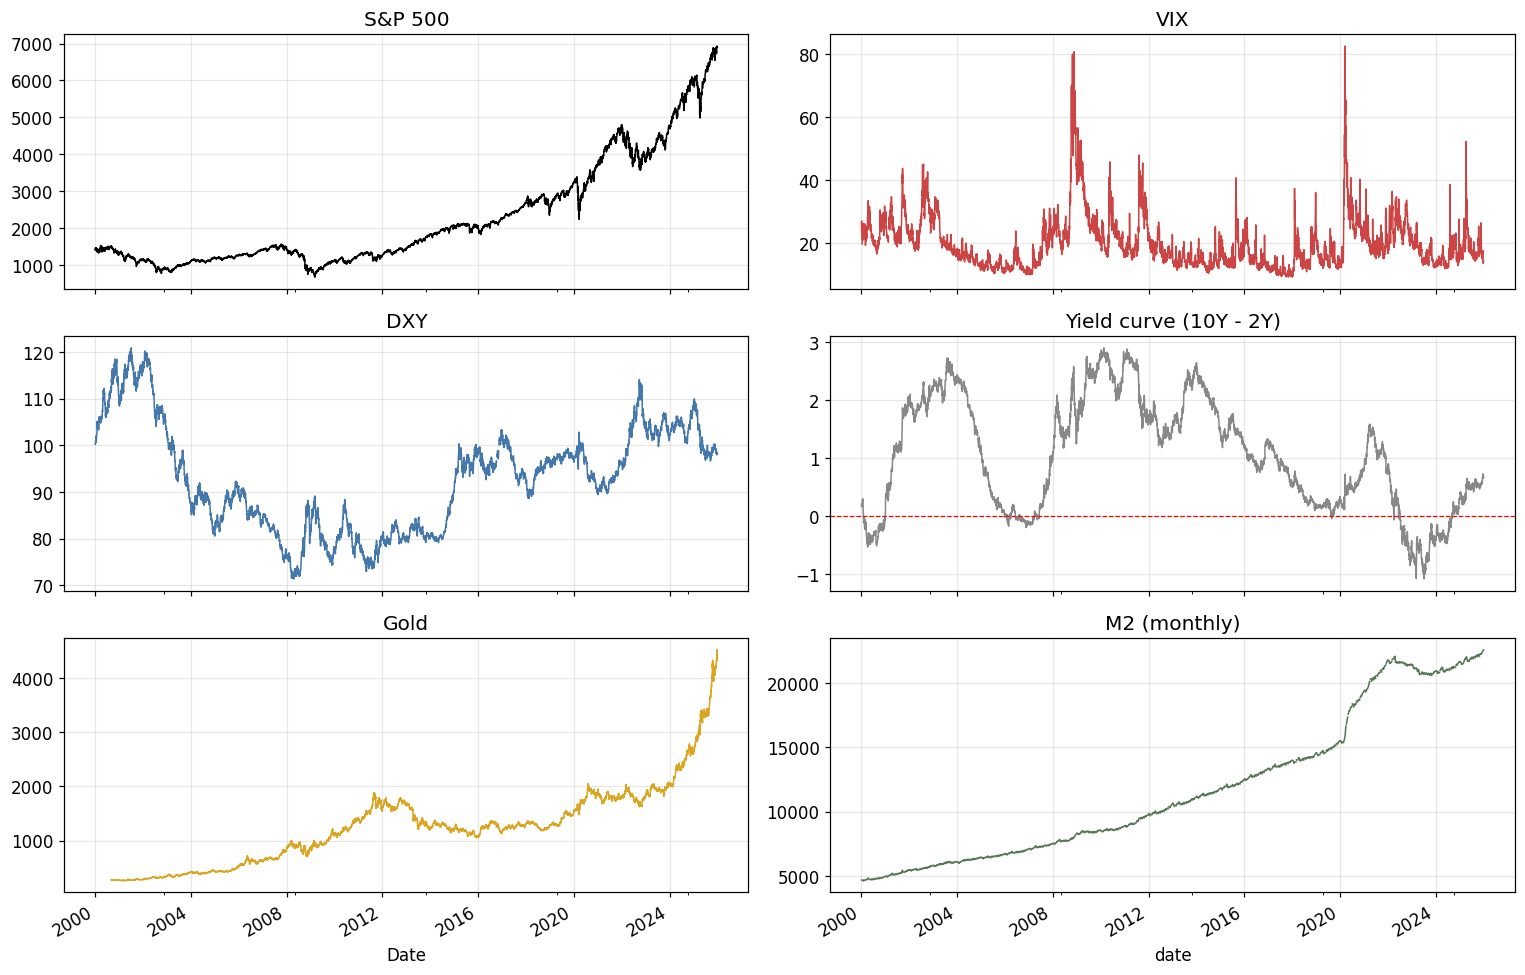

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
macro_risk["SP500"].plot(ax=axes[0,0], color="black", lw=1.0); axes[0,0].set_title("S&P 500")
macro_risk["VIX"].plot(ax=axes[0,1], color="#cc4444", lw=1.0); axes[0,1].set_title("VIX")
macro_risk["DXY"].plot(ax=axes[1,0], color="#4477aa", lw=1.0); axes[1,0].set_title("DXY")
(macro_yields["US10Y"] - macro_yields["US2Y"]).plot(ax=axes[1,1], color="#888", lw=1.0)
axes[1,1].axhline(0, color="red", ls="--", lw=0.8); axes[1,1].set_title("Yield curve (10Y - 2Y)")
macro_comms["Gold"].plot(ax=axes[2,0], color="#daa520", lw=1.0); axes[2,0].set_title("Gold")
macro_monthly["WM2NS"].plot(ax=axes[2,1], color="#557755", lw=1.0); axes[2,1].set_title("M2 (monthly)")
fig.tight_layout()
plt.show()

## 3. Aligned & derived features (processed)

- `btc_aligned_v5.csv` / `eth_aligned_v5.csv`: BTC/ETH OHLCV + 12 macro features
- `macro_derived_pretrain_v5.csv`: Stage 2 pretrain macro features (Jan 2000 → Dec 2025), no crypto, used for FSM fit

In [5]:
btc = pd.read_csv(proc / "btc_aligned_v5.csv", index_col=0, parse_dates=True)
eth = pd.read_csv(proc / "eth_aligned_v5.csv", index_col=0, parse_dates=True)
pretrain = pd.read_csv(proc / "macro_derived_pretrain_v5.csv", index_col=0, parse_dates=True)

summary = pd.DataFrame({
    "rows":   [len(btc), len(eth), len(pretrain)],
    "cols":   [btc.shape[1], eth.shape[1], pretrain.shape[1]],
    "start":  [btc.index.min().date(), eth.index.min().date(), pretrain.index.min().date()],
    "end":    [btc.index.max().date(), eth.index.max().date(), pretrain.index.max().date()],
    "nan_pct": [f"{btc.isna().mean().mean()*100:.2f}%",
                f"{eth.isna().mean().mean()*100:.2f}%",
                f"{pretrain.isna().mean().mean()*100:.2f}%"],
}, index=["btc_aligned_v5", "eth_aligned_v5", "macro_derived_pretrain_v5"])
summary

,rows,cols,start,end,nan_pct
btc_aligned_v5,4094,17,2014-09-17,2025-12-30,0.00%
eth_aligned_v5,2955,17,2017-11-09,2025-12-30,0.00%
macro_derived_pretrain_v5,6783,12,2000-01-03,2025-12-31,1.64%


## 4. Sanity checks

- Chronological index, no duplicates
- BTC era starts 2014-09-17, ETH era starts 2017-08-17, pretrain starts 2000-01-03
- Macro alignment validated against raw

In [6]:
assert btc.index.is_monotonic_increasing and not btc.index.duplicated().any()
assert eth.index.is_monotonic_increasing and not eth.index.duplicated().any()
assert pretrain.index.is_monotonic_increasing and not pretrain.index.duplicated().any()
print("OK: chronological + no duplicates")

# Macro features in btc_aligned use timezone-lagged forward-fill (anchor leak fix).
# Spot-check: VIX values in btc_aligned should match raw at corresponding lag.
vix_raw = macro_risk["VIX"]
print(f"VIX range raw:        [{vix_raw.min():.2f}, {vix_raw.max():.2f}]")
print(f"VIX range btc_aligned: [{btc['VIX'].min():.2f}, {btc['VIX'].max():.2f}]")
print(f"All macro features non-null in btc_aligned: {(~btc.isna().any()).all()}")

OK: chronological + no duplicates
VIX range raw:        [9.14, 82.69]
VIX range btc_aligned: [9.14, 82.69]
All macro features non-null in btc_aligned: True


## Summary

V5 data pipeline outputs hazır:
- BTC: 4094 daily rows (2014-09-17 → 2025-12-30)
- ETH: 3060 daily rows (2017-08-17 → 2025-12-30)
- Macro pretrain: 6783 daily rows (2000-01-03 → 2025-12-31)

Bu CSV'ler Stage 2 (macro regime, Phase 2.12) ve Stage 1/3 (gelecek phase'ler) için input olarak kullanılır.